# 03 — Propensity Score Model
Estimate P(outreach=1|X) using TabPFN, diagnose overlap, set trim thresholds.

In [1]:
import sys, warnings
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
from tabpfn import TabPFNClassifier
from feature_engineering import FEATURE_COLS
sns.set_style('whitegrid')
np.random.seed(42)


In [2]:
train = pd.read_parquet('train_features.parquet')
X = train[FEATURE_COLS].values.astype(float)
T = train['outreach'].values
print(f"Train shape: {X.shape}, treatment rate: {T.mean():.4f}")


Train shape: (10000, 14), treatment rate: 0.3984


In [3]:
# Cross-validated propensity scores with TabPFN
print("Fitting propensity model (TabPFN, 5-fold CV)...")
ps_oof = np.zeros(len(X))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, T)):
    mdl = TabPFNClassifier(n_estimators=8, random_state=42)
    mdl.fit(X[tr_idx], T[tr_idx])
    ps_oof[val_idx] = mdl.predict_proba(X[val_idx])[:, 1]
    print(f"  Fold {fold+1}: AUC={roc_auc_score(T[val_idx], ps_oof[val_idx]):.4f}")

print(f"\nOverall AUC: {roc_auc_score(T, ps_oof):.4f}")
print(f"Brier score: {brier_score_loss(T, ps_oof):.4f}")
train['propensity'] = ps_oof


Fitting propensity model (TabPFN, 5-fold CV)...


  Fold 1: AUC=0.6309


  Fold 2: AUC=0.6326


  Fold 3: AUC=0.6519


  Fold 4: AUC=0.6394


  Fold 5: AUC=0.6412

Overall AUC: 0.6389
Brier score: 0.2262


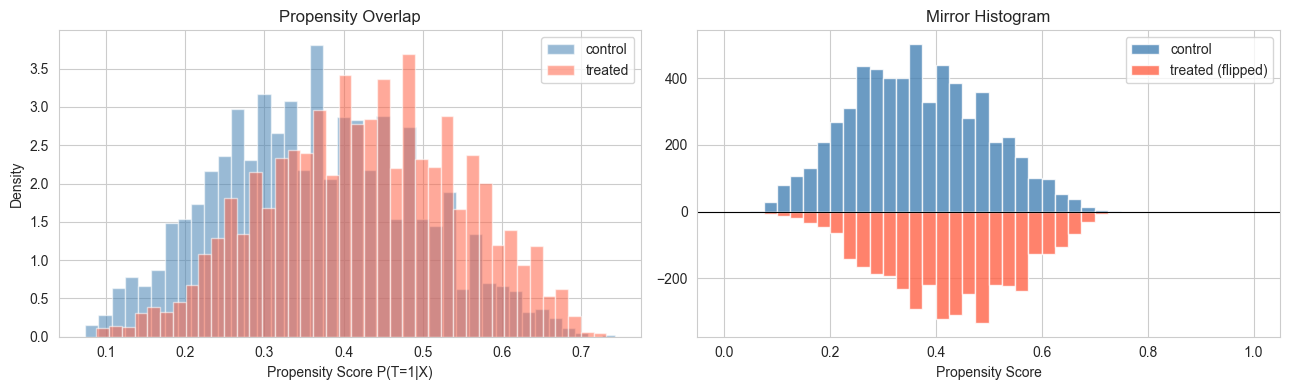

In [4]:
# Propensity distribution by treatment
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for trt, label, color in [(0,'control','steelblue'),(1,'treated','tomato')]:
    ax.hist(train[train['outreach']==trt]['propensity'], bins=40,
            alpha=0.55, density=True, label=label, color=color)
ax.set_xlabel('Propensity Score P(T=1|X)')
ax.set_ylabel('Density')
ax.set_title('Propensity Overlap')
ax.legend()

ax = axes[1]
# Mirror plot (treated up, control down)
ctrl = train[train['outreach']==0]['propensity']
trtd = train[train['outreach']==1]['propensity']
bins = np.linspace(0, 1, 41)
ax.hist(ctrl, bins=bins, color='steelblue', alpha=0.8, label='control')
ax.hist(trtd, bins=bins, color='tomato', alpha=0.8, weights=-np.ones(len(trtd)), label='treated (flipped)')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Propensity Score')
ax.set_title('Mirror Histogram')
ax.legend()

plt.tight_layout()
plt.savefig('propensity_overlap.png', bbox_inches='tight')
plt.show()


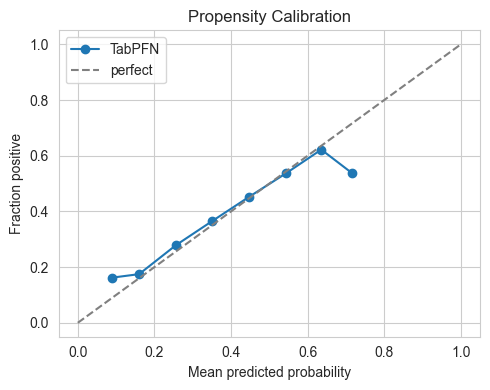

In [5]:
# Calibration
prob_true, prob_pred = calibration_curve(T, ps_oof, n_bins=10)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(prob_pred, prob_true, 'o-', label='TabPFN')
ax.plot([0,1],[0,1],'--', color='gray', label='perfect')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction positive')
ax.set_title('Propensity Calibration')
ax.legend()
plt.tight_layout()
plt.savefig('propensity_calibration.png', bbox_inches='tight')
plt.show()


In [6]:
# Trim thresholds
TRIM_LO, TRIM_HI = 0.05, 0.95
trimmed = train[(train['propensity'] > TRIM_LO) & (train['propensity'] < TRIM_HI)]
print(f"Before trim: {len(train):,} members")
print(f"After trim (ps in ({TRIM_LO}, {TRIM_HI})): {len(trimmed):,} members")
print(f"Dropped: {len(train)-len(trimmed):,} ({(len(train)-len(trimmed))/len(train):.2%})")
print(f"\nTrimmed treatment rate: {trimmed['outreach'].mean():.4f}")
print(f"Trimmed churn rate:     {trimmed['churn'].mean():.4f}")


Before trim: 10,000 members
After trim (ps in (0.05, 0.95)): 10,000 members
Dropped: 0 (0.00%)

Trimmed treatment rate: 0.3984
Trimmed churn rate:     0.2021


In [7]:
# Propensity percentiles for IPW
print("Propensity score percentiles:")
pcts = [1, 5, 10, 25, 50, 75, 90, 95, 99]
print(pd.Series(ps_oof).quantile([p/100 for p in pcts]).rename('ps').to_frame().T.round(4))

# IPW weights
eps = 1e-6
w = np.where(
    T == 1,
    1 / (ps_oof + eps),
    1 / (1 - ps_oof + eps)
)
print(f"\nIPW weight stats (untrimmed): mean={w.mean():.2f}, max={w.max():.2f}, 99th pct={np.percentile(w,99):.2f}")

# Stabilized weights
w_stab = np.where(T == 1, T.mean() / (ps_oof + eps), (1 - T.mean()) / (1 - ps_oof + eps))
print(f"Stabilized IPW: mean={w_stab.mean():.2f}, max={w_stab.max():.2f}")


Propensity score percentiles:
      0.01    0.05    0.10    0.25    0.50    0.75    0.90    0.95   0.99
ps  0.1185  0.1818  0.2242  0.2941  0.3898  0.4831  0.5646  0.6046  0.665

IPW weight stats (untrimmed): mean=2.03, max=11.38, 99th pct=5.19
Stabilized IPW: mean=1.01, max=4.53


In [8]:
# Save propensity + trim mask
train.to_parquet('train_features.parquet', index=False)  # propensity column added
trim_mask = (train['propensity'] > TRIM_LO) & (train['propensity'] < TRIM_HI)
trim_mask.to_frame('in_support').assign(member_id=train['member_id']).to_parquet('trim_mask.parquet', index=False)
print("Saved updated train_features.parquet and trim_mask.parquet")
print(f"Propensity range in support: [{train.loc[trim_mask,'propensity'].min():.4f}, {train.loc[trim_mask,'propensity'].max():.4f}]")


Saved updated train_features.parquet and trim_mask.parquet
Propensity range in support: [0.0736, 0.7423]
